In [ ]:
# ============================================
# 0) Librairies (Colab)
# ============================================
# Importer les bibliothèques nécessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

In [ ]:
# Charger les données dans un DataFrame
df = pd.read_csv('payment_fraud.csv')

In [ ]:
# Afficher les 5 premières lignes du DataFrame
df.head()

,accountAgeDays,numItems,localTime,paymentMethod,paymentMethodAgeDays,label
0,29,1,4.745402,paypal,28.204861,0
1,725,1,4.742303,storecredit,0.000000,0
2,845,1,4.921318,creditcard,0.000000,0
3,503,1,4.886641,creditcard,0.000000,0
4,2000,1,5.040929,creditcard,0.000000,0


In [ ]:
# Afficher la structure des données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39221 entries, 0 to 39220
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   accountAgeDays        39221 non-null  int64  
 1   numItems              39221 non-null  int64  
 2   localTime             39221 non-null  float64
 3   paymentMethod         39221 non-null  object 
 4   paymentMethodAgeDays  39221 non-null  float64
 5   label                 39221 non-null  int64  
dtypes: float64(2), int64(3), object(1)
memory usage: 1.8+ MB


In [ ]:
# Obtenir des statistiques descriptives
df.describe()

,accountAgeDays,numItems,localTime,paymentMethodAgeDays,label
count,39221.000000,39221.000000,39221.000000,39221.000000,39221.000000
mean,857.563984,1.084751,4.748232,122.641326,0.014278
std,804.788212,0.566899,0.389360,283.569177,0.118636
min,1.000000,1.000000,0.421214,0.000000,0.000000
25%,72.000000,1.000000,4.742303,0.000000,0.000000
50%,603.000000,1.000000,4.886641,0.012500,0.000000
75%,1804.000000,1.000000,4.962055,87.510417,0.000000
max,2000.000000,29.000000,5.040929,1999.580556,1.000000


In [ ]:
# Vérifier les valeurs manquantes
df.isnull().sum()

,0
accountAgeDays,0
numItems,0
localTime,0
paymentMethod,0
paymentMethodAgeDays,0
label,0


In [ ]:
# Répartition des labels (0 : légitime, 1 : fraude)
df['label'].value_counts()

,count
label,
0,38661
1,560


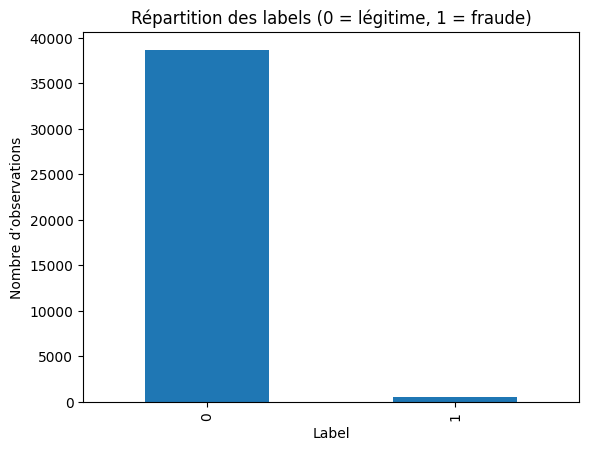

In [ ]:
df['label'].value_counts().plot(
    kind='bar',
    title='Répartition des labels (0 = légitime, 1 = fraude)',
    xlabel='Label',
    ylabel='Nombre d’observations'
)
plt.show()

In [ ]:
for col in df.columns:
    print(repr(col))


'accountAgeDays'
'numItems'
'localTime'
'paymentMethodAgeDays'
'label'
'paymentMethod_creditcard'
'paymentMethod_paypal'
'paymentMethod_storecredit'


In [ ]:
df = pd.read_csv('payment_fraud.csv')

In [ ]:
df = pd.get_dummies(df, columns=['paymentMethod'])

In [ ]:
df.head()

,accountAgeDays,numItems,localTime,paymentMethodAgeDays,label,paymentMethod_creditcard,paymentMethod_paypal,paymentMethod_storecredit
0,29,1,4.745402,28.204861,0,False,True,False
1,725,1,4.742303,0.000000,0,False,False,True
2,845,1,4.921318,0.000000,0,True,False,False
3,503,1,4.886641,0.000000,0,True,False,False
4,2000,1,5.040929,0.000000,0,True,False,False


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('label', axis=1), df['label'], test_size=0.33)

In [ ]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = clf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
print(accuracy_score(y_pred, y_test))

1.0


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
print(accuracy_score(y_pred, y_test))

1.0


In [ ]:
print(confusion_matrix(y_test, y_pred))

[[12760     0]
 [    0   183]]
